# Import dan Dataset

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import zipfile
from skimage.transform import resize
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

In [2]:
!kaggle datasets download uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 428M/429M [00:19<00:00, 23.9MB/s]
100% 429M/429M [00:19<00:00, 22.7MB/s]


In [3]:
with zipfile.ZipFile("ravdess-emotional-speech-audio.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/ravdess-emotional-speech-audio")

# With Optuna Tunning Hyperparameter

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.1 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
# Fungsi untuk mengekstraksi fitur Mel-spectrogram
def extract_features(file, sample_rate=22050, n_mels=128, fmax=8000, resize_shape=(300, 300)):
    audio_data, sr = librosa.load(file, sr=sample_rate)
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sr, n_mels=n_mels, fmax=fmax)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    resized_spectrogram = resize(log_mel_spectrogram, resize_shape)
    resized_spectrogram = np.expand_dims(resized_spectrogram, axis=-1)
    return np.repeat(resized_spectrogram, 3, axis=-1)

In [ ]:
# Membuat DataFrame dari dataset RAVDESS
def process_ravdess_dataset(dataset_path):
    emotions = []
    features = []

    # Mapping untuk emosi dalam RAVDESS
    emotion_mapping = {
        '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
        '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
    }

    # Menelusuri semua file audio di folder dataset
    for root, _, files in os.walk(dataset_path):
        for file in tqdm(files, desc="Processing RAVDESS Dataset"):
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                # Ekstraksi emosi dari nama file (format: Actor_XX_Emotion_YY_...)
                emotion_code = file.split('-')[2]
                emotion_label = emotion_mapping.get(emotion_code, 'unknown')
                if emotion_label != 'unknown':  # Abaikan file dengan label yang tidak diketahui
                    features.append(extract_features(file_path))
                    emotions.append(emotion_label)

    # Membuat DataFrame
    return pd.DataFrame({
        'spectrogram': features,
        'class': emotions
    })

# Contoh penggunaan
dataset_path = '/content/ravdess-emotional-speech-audio'  # Ganti dengan path ke dataset RAVDESS Anda
data_df = process_ravdess_dataset(dataset_path)

print(data_df.head())

Processing RAVDESS Dataset: 0it [00:00, ?it/s]
Processing RAVDESS Dataset: 100%|██████████| 60/60 [00:01<00:00, 49.63it/s]
Processing RAVDESS Dataset: 0it [00:00, ?it/s]
Processing RAVDESS Dataset: 100%|██████████| 60/60 [00:01<00:00, 49.73it/s]


                                         spectrogram      class
0  [[[-79.76592, -79.76592, -79.76592], [-79.7596...       calm
1  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...  surprised
2  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...      angry
3  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...    disgust
4  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...      happy


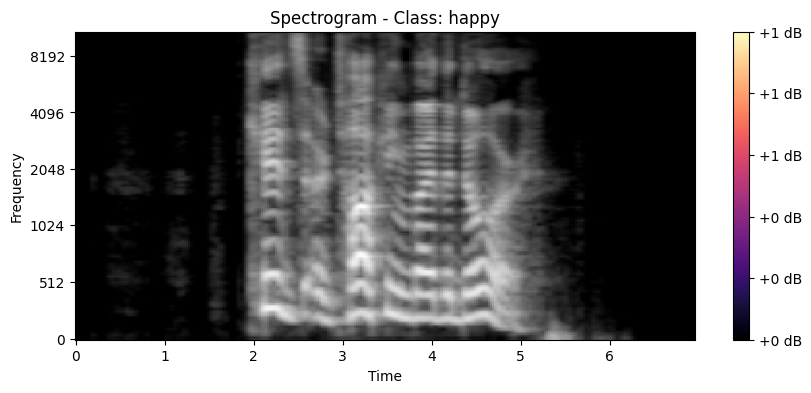

In [ ]:
#Nenasukkan data index yang inginkan
random_index=10
# Modifikasi fungsi visualisasi untuk menormalkan spektrogram
def visualize_spectrogram(spectrogram, label):
    # Normalisasi nilai spektrogram ke rentang 0..1
    spectrogram = (spectrogram - np.min(spectrogram)) / (np.max(spectrogram) - np.min(spectrogram))

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram, sr=22050, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram - Class: {label}")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

# Menampilkan spektrogram dari contoh dengan indeks acak
visualize_spectrogram(data_df['spectrogram'][random_index], data_df['class'][random_index])

In [ ]:
# Menyiapkan data dan label
X = np.array([s for s in data_df['spectrogram']])
y = np.array(data_df['class'])

# Mengkodekan label emosi
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
# Optuna objective function
def objective(trial):
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    dense_units = trial.suggest_int('dense_units', 64, 256, step=64)

    base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
    base_model.trainable = False

    inputs = Input(shape=(300, 300, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(len(label_encoder.classes_), activation='softmax')(x)
    model = Model(inputs, outputs)

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    return accuracy



In [ ]:
X_train.shape

(2304, 300, 300, 3)

In [ ]:
# Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Menampilkan hasil terbaik
print("Best hyperparameters:", study.best_params)

# Membuat model akhir dengan hyperparameter terbaik
best_params = study.best_params


[I 2024-12-17 12:16:47,958] A new study created in memory with name: no-name-e7197f38-d583-4a0a-aa1a-7fca8c014ccc


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[I 2024-12-17 12:25:48,116] Trial 0 finished with value: 0.578125 and parameters: {'dropout_rate': 0.41628636393362783, 'learning_rate': 4.177253326383527e-05, 'dense_units': 128}. Best is trial 0 with value: 0.578125.
[I 2024-12-17 12:34:28,821] Trial 1 finished with value: 0.515625 and parameters: {'dropout_rate': 0.22771898381564792, 'learning_rate': 1.0439921764992742e-05, 'dense_units': 256}. Best is trial 0 with value: 0.578125.
[I 2024-12-17 12:43:05,196] Trial 2 finished with value: 0.5572916865348816 and parameters: {'dropout_rate': 0.4569630463817831, 'learning_rate': 2.0543179317187807e-05, 'dense_units': 256}. Best is trial 0 with value: 0.578125.
[I 2024-12-17 12:51:47,963] Trial 3 finished with value: 0.5104166865348816 and parameters: {'dropout_rate': 0.3186715820573263, 'learning_rate': 1.8176146990612607e-05, 'dense_units': 64}. Best is trial 0 with value: 0.578125.
[I 2024-12-17 13:00:26,609] Trial 4 finished with value: 0.7638888955116272 and parameters: {'dropout_ra

Best hyperparameters: {'dropout_rate': 0.23821301797425667, 'learning_rate': 0.0009843392743937327, 'dense_units': 192}


In [ ]:
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
base_model.trainable = False  # Membekukan EfficientNetB3 untuk transfer learning

# Model
inputs = Input(shape=(300, 300, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(best_params['dense_units'], activation='relu')(x)
x = Dropout(best_params['dropout_rate'])(x)
outputs = Dense(len(label_encoder.classes_), activation='softmax')(x)
final_model = Model(inputs, outputs)

# Kompilasi model
final_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Melatih model akhir
history = final_model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2)

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 63s 312ms/step - accuracy: 0.2812 - loss: 1.8803 - val_accuracy: 0.4143 - val_loss: 1.4871
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.4537 - loss: 1.4912 - val_accuracy: 0.5336 - val_loss: 1.2757
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.5033 - loss: 1.3108 - val_accuracy: 0.5228 - val_loss: 1.2612
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.5670 - loss: 1.2412 - val_accuracy: 0.6095 - val_loss: 1.1217
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.5530 - loss: 1.1910 - val_accuracy: 0.6139 - val_loss: 1.0694
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.5865 - loss: 1.1220 - val_accuracy: 0.5835 - val_loss: 1.0569
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.6133 - loss: 1.0721 - val_accuracy: 0.6182 - val_loss: 1.0399
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.6099 - loss: 1.037

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.8366 - loss: 0.5873
Test accuracy: 0.8524, Test loss: 0.5078
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step
F1 Score: 0.8529
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        77
           1       0.85      0.87      0.86        77
           2       0.87      0.93      0.90        70
           3       0.75      1.00      0.86        74
           4       0.82      0.77      0.80        79
           5       0.73      0.78      0.75        45
           6       0.97      0.77      0.86        77
           7       1.00      0.84      0.92        77

    accuracy                           0.85       576
   macro avg       0.86      0.85      0.85       576
weighted avg       0.86      0.85      0.85       576



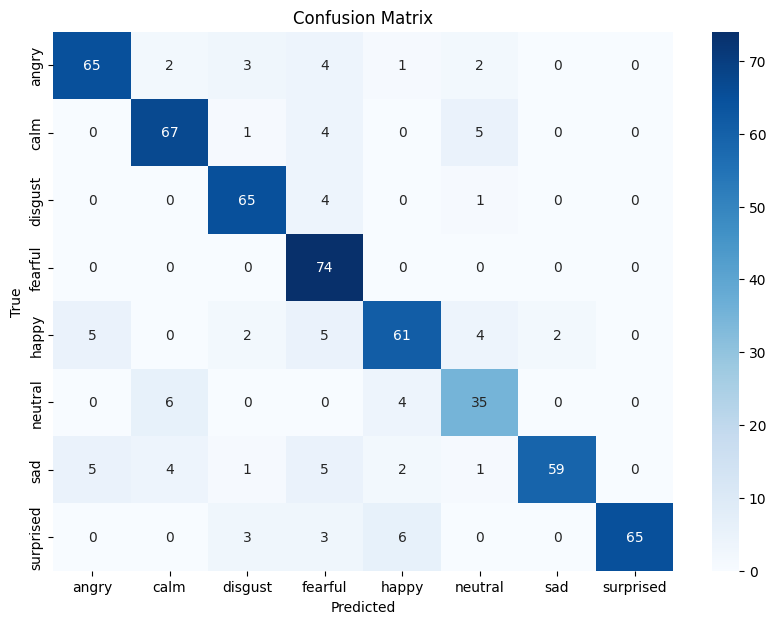

In [ ]:
# Evaluasi model pada set pengujian
loss, test_accuracy = final_model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {loss:.4f}")

# Prediksi untuk data uji
y_pred = final_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Mengambil kelas dengan probabilitas tertinggi

# Menghitung F1 Score
f1 = f1_score(y_test, y_pred_classes, average='weighted')  # Menggunakan rata-rata berbobot
print(f"F1 Score: {f1:.4f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

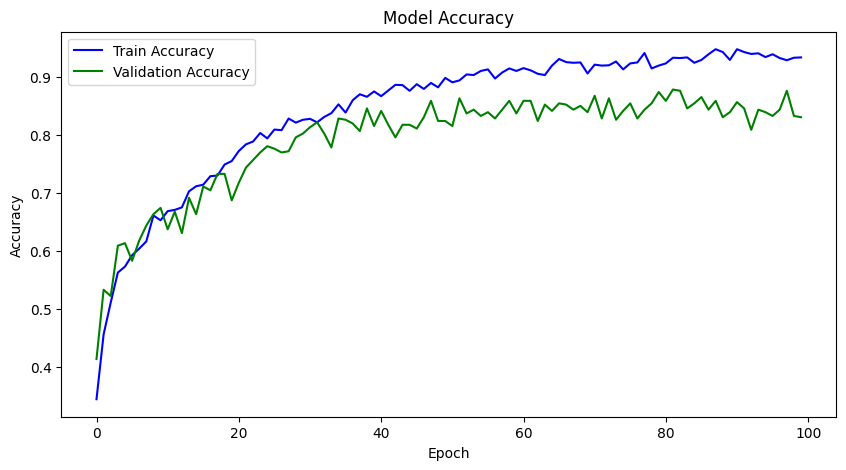

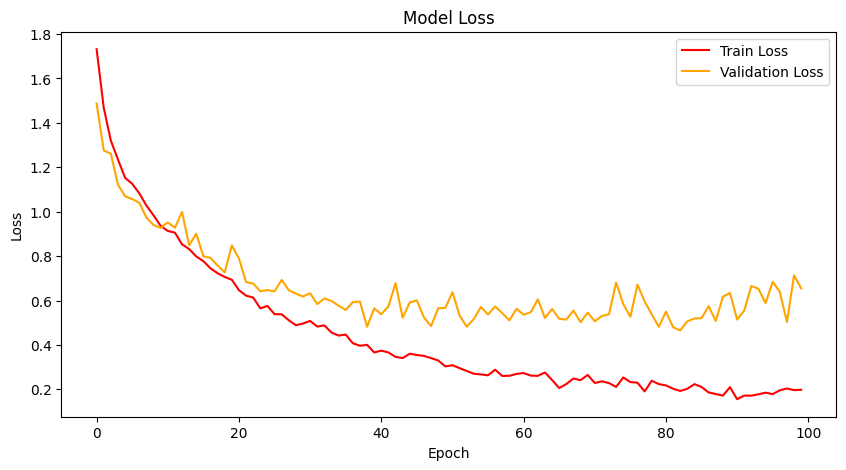

In [ ]:
# Visualisasi akurasi dan kehilangan selama pelatihan
# Plot akurasi
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Plot kehilangan
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# With Optuna dan XGBoost

In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 8.1 MB/s eta 0:00:00


In [5]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [6]:
# Fungsi untuk mengekstraksi fitur Mel-spectrogram
def extract_features(file, sample_rate=22050, n_mels=128, fmax=8000, resize_shape=(300, 300)):
    audio_data, sr = librosa.load(file, sr=sample_rate)
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sr, n_mels=n_mels, fmax=fmax)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    resized_spectrogram = resize(log_mel_spectrogram, resize_shape)
    resized_spectrogram = np.expand_dims(resized_spectrogram, axis=-1)
    return np.repeat(resized_spectrogram, 3, axis=-1)

In [7]:
# Membuat DataFrame dari dataset RAVDESS
def process_ravdess_dataset(dataset_path):
    emotions = []
    features = []

    # Mapping untuk emosi dalam RAVDESS
    emotion_mapping = {
        '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
        '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
    }

    # Menelusuri semua file audio di folder dataset
    for root, _, files in os.walk(dataset_path):
        for file in tqdm(files, desc="Processing RAVDESS Dataset"):
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                # Ekstraksi emosi dari nama file (format: Actor_XX_Emotion_YY_...)
                emotion_code = file.split('-')[2]
                emotion_label = emotion_mapping.get(emotion_code, 'unknown')
                if emotion_label != 'unknown':  # Abaikan file dengan label yang tidak diketahui
                    features.append(extract_features(file_path))
                    emotions.append(emotion_label)

    # Membuat DataFrame
    return pd.DataFrame({
        'spectrogram': features,
        'class': emotions
    })

# Contoh penggunaan
dataset_path = '/content/ravdess-emotional-speech-audio'  # Ganti dengan path ke dataset RAVDESS Anda
data_df = process_ravdess_dataset(dataset_path)

print(data_df.head())

Processing RAVDESS Dataset: 0it [00:00, ?it/s]
Processing RAVDESS Dataset: 100%|██████████| 60/60 [00:01<00:00, 46.85it/s]
Processing RAVDESS Dataset: 0it [00:00, ?it/s]
Processing RAVDESS Dataset: 100%|██████████| 60/60 [00:01<00:00, 46.68it/s]


                                         spectrogram      class
0  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...  surprised
1  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...    disgust
2  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...    fearful
3  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...    neutral
4  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...    disgust


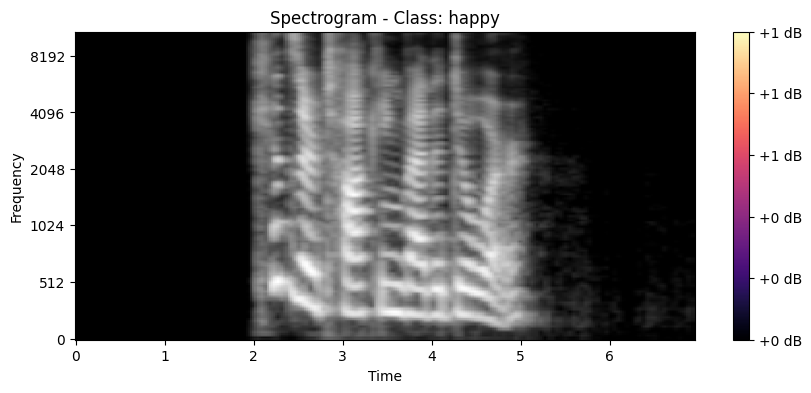

In [8]:
#Nenasukkan data index yang inginkan
random_index=10
# Modifikasi fungsi visualisasi untuk menormalkan spektrogram
def visualize_spectrogram(spectrogram, label):
    # Normalisasi nilai spektrogram ke rentang 0..1
    spectrogram = (spectrogram - np.min(spectrogram)) / (np.max(spectrogram) - np.min(spectrogram))

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram, sr=22050, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram - Class: {label}")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

# Menampilkan spektrogram dari contoh dengan indeks acak
visualize_spectrogram(data_df['spectrogram'][random_index], data_df['class'][random_index])

In [9]:
# Menyiapkan data dan label
X = np.array([s for s in data_df['spectrogram']])
y = np.array(data_df['class'])

# Mengkodekan label emosi
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

Tanpa Fine Tuning

In [10]:
# Menggunakan EfficientNetB3 untuk ekstraksi fitur
#base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
#base_model.trainable = False

#inputs = Input(shape=(300, 300, 3))
#efficient_features = base_model(inputs, training=False)
#efficient_features = GlobalAveragePooling2D()(efficient_features)
#feature_extractor_model = Model(inputs, efficient_features)

# Ekstraksi fitur dari EfficientNetB3
#X_train_features = feature_extractor_model.predict(X_train)
#X_test_features = feature_extractor_model.predict(X_test)

Dengan Fine Tuning

In [11]:
# Menggunakan EfficientNetB3 untuk ekstraksi fitur
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [12]:
# Model awal tanpa Fine-Tuning
inputs = Input(shape=(300, 300, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(len(label_encoder.classes_), activation='softmax')(x)

feature_extractor_model = Model(inputs, outputs)
feature_extractor_model.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [13]:
# Latih model awal
feature_extractor_model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 88s 852ms/step - accuracy: 0.2534 - loss: 1.9590 - val_accuracy: 0.4360 - val_loss: 1.5334
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.4421 - loss: 1.5418 - val_accuracy: 0.4902 - val_loss: 1.4205
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.4884 - loss: 1.4158 - val_accuracy: 0.5076 - val_loss: 1.3378
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.5532 - loss: 1.2902 - val_accuracy: 0.5380 - val_loss: 1.2479
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.5675 - loss: 1.2305 - val_accuracy: 0.5054 - val_loss: 1.3073
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.5772 - loss: 1.1535 - val_accuracy: 0.5575 - val_loss: 1.1926
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.5806 - loss: 1.1400 - val_accuracy: 0.5640 - val_loss: 1.1477
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.6066 - loss: 1.1200 - val_accuracy: 0

In [14]:
# Fine-Tuning EfficientNetB3
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [15]:
# Latih model awal
feature_extractor_model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
feature_extractor_model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 77s 729ms/step - accuracy: 0.5876 - loss: 1.1676 - val_accuracy: 0.6725 - val_loss: 0.8865
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.7026 - loss: 0.8342 - val_accuracy: 0.6811 - val_loss: 0.8765
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.7411 - loss: 0.7709 - val_accuracy: 0.7050 - val_loss: 0.8524
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.7282 - loss: 0.7718 - val_accuracy: 0.7115 - val_loss: 0.8273
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.7278 - loss: 0.7323 - val_accuracy: 0.7267 - val_loss: 0.8104
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.7362 - loss: 0.7440 - val_accuracy: 0.7354 - val_loss: 0.7944
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.7680 - loss: 0.6732 - val_accuracy: 0.7397 - val_loss: 0.7746
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.7871 - loss: 0.6529 - val_accu

In [16]:
# Ekstraksi fitur dari EfficientNetB3
X_train_features = feature_extractor_model.predict(X_train)
X_test_features = feature_extractor_model.predict(X_test)

72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step


In [17]:
# Fungsi untuk Optuna dan XGBoost
def objective(trial):
    # Hyperparameter yang akan dicoba oleh Optuna
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    # Model XGBoost
    xgb_model = XGBClassifier(**params, random_state=42)
    xgb_model.fit(X_train_features, y_train, verbose=False)

    # Evaluasi akurasi
    y_pred = xgb_model.predict(X_test_features)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy


In [18]:
# Optuna study untuk tuning hyperparameter
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Menampilkan hasil terbaik
print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2024-12-18 05:35:45,588] A new study created in memory with name: no-name-d038fc88-d28a-41a9-b6e6-c69793564710
[I 2024-12-18 05:35:45,992] Trial 0 finished with value: 0.9305555555555556 and parameters: {'n_estimators': 150, 'learning_rate': 0.2861109032210748, 'max_depth': 6, 'subsample': 0.8840399188614363, 'colsample_bytree': 0.556061058500288}. Best is trial 0 with value: 0.9305555555555556.
[I 2024-12-18 05:35:46,528] Trial 1 finished with value: 0.9305555555555556 and parameters: {'n_estimators': 300, 'learning_rate': 0.2569959773763466, 'max_depth': 3, 'subsample': 0.687416067258023, 'colsample_bytree': 0.7321989266814123}. Best is trial 0 with value: 0.9305555555555556.
[I 2024-12-18 05:35:46,757] Trial 2 finished with value: 0.8836805555555556 and parameters: {'n_estimators': 50, 'learning_rate': 0.09616780793630254, 'max_depth': 10, 'subsample': 0.5414179247451785, 'colsample_bytree': 0.9149939918909388}. Best is trial 0 with value: 0.9305555555555556.
[I 2024-12-18 05:35:

Best hyperparameters: {'n_estimators': 250, 'learning_rate': 0.12608480724773194, 'max_depth': 5, 'subsample': 0.6987800267360377, 'colsample_bytree': 0.7715674700799008}
Best accuracy: 0.9340277777777778


In [19]:
# Melatih model akhir dengan hyperparameter terbaik
best_params = study.best_params
final_xgb_model = XGBClassifier(**best_params, random_state=42)
final_xgb_model.fit(X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7715674700799008, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.12608480724773194,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

Final XGBoost Accuracy with EfficientNetB3 Features: 0.9340
Training Accuracy: 1.0000
Test Accuracy: 0.9340
F1 Score: 0.9342


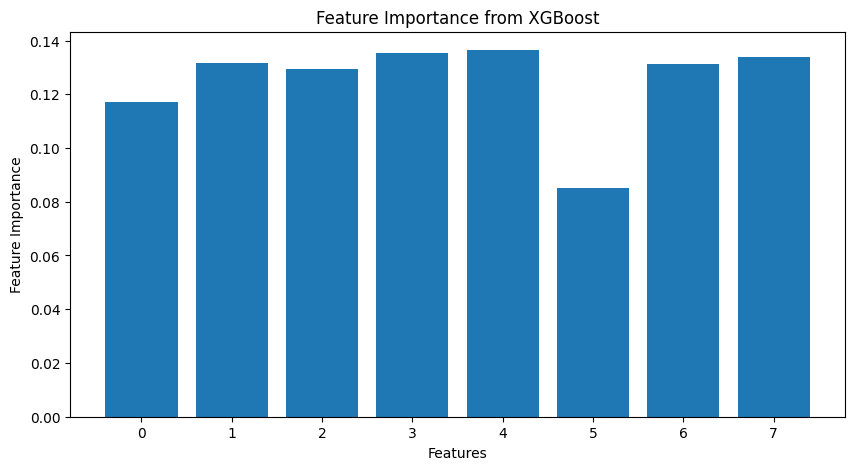

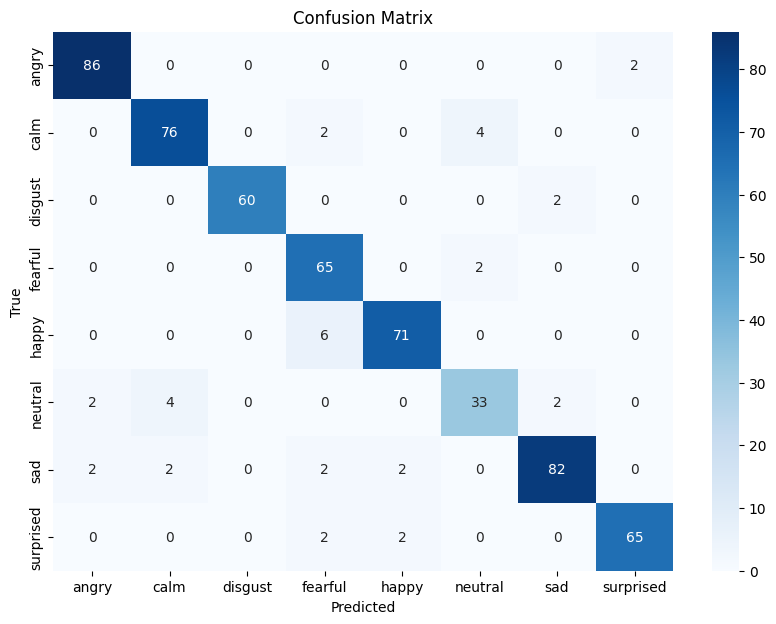

Classification Report:
              precision    recall  f1-score   support

       angry       0.96      0.98      0.97        88
        calm       0.93      0.93      0.93        82
     disgust       1.00      0.97      0.98        62
     fearful       0.84      0.97      0.90        67
       happy       0.95      0.92      0.93        77
     neutral       0.85      0.80      0.82        41
         sad       0.95      0.91      0.93        90
   surprised       0.97      0.94      0.96        69

    accuracy                           0.93       576
   macro avg       0.93      0.93      0.93       576
weighted avg       0.94      0.93      0.93       576



In [20]:
# Evaluasi model akhir
y_pred = final_xgb_model.predict(X_test_features)
final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final XGBoost Accuracy with EfficientNetB3 Features: {final_accuracy:.4f}")

# Evaluasi Training Accuracy
y_train_pred = final_xgb_model.predict(X_train_features)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Evaluasi Test Accuracy
y_test_pred = final_xgb_model.predict(X_test_features)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Menampilkan Akurasi
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Menghitung F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')  # Menggunakan prediksi y_pred
print(f"F1 Score: {f1:.4f}")

# Visualisasi Feature Importance
plt.figure(figsize=(10, 5))
plt.bar(range(len(final_xgb_model.feature_importances_)), final_xgb_model.feature_importances_)
plt.xlabel('Features')
plt.ylabel('Feature Importance')
plt.title('Feature Importance from XGBoost')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))